In [1]:
import sys
import os

# Go up three levels from the notebook's directory (src/concept_creator/src) to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '../../..')) 
# Add the src directory to the path
src_path = os.path.join(project_root, 'src') 
if src_path not in sys.path:
    sys.path.insert(0, src_path)
    
# Optional: Add the specific package's src dir too, sometimes helps resolve sibling imports
concept_creator_src_path = os.path.join(project_root, 'src', 'concept_creator')
if concept_creator_src_path not in sys.path:
     sys.path.insert(0, concept_creator_src_path)
        
print(f"Project Root: {project_root}")
print(f"Src Path added: {src_path}")
print(f"Concept Creator Src Path added: {concept_creator_src_path}") # Uncomment if added above
print(f"sys.path[0]: {sys.path[0]}") 

Project Root: /Users/mlapin/Development/personal/NaturalAGI
Src Path added: /Users/mlapin/Development/personal/NaturalAGI/src
Concept Creator Src Path added: /Users/mlapin/Development/personal/NaturalAGI/src/concept_creator
sys.path[0]: /Users/mlapin/Development/personal/NaturalAGI/src/concept_creator


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import json

from concept_creator.src.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"

In [3]:
def visualize_graph(graph: nx.Graph, ax: plt.Axes=None, image_id: str = None, title: str = None, is_spring_layout: bool = False):
    if ax is None:
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111)
    
    if graph is None:
        graph = nx.Graph()
    
    # Extract node positions from the graph
    pos = {}
    for node_id, node_data in graph.nodes(data=True):
        # For regular points
        if 'x' in node_data and 'y' in node_data:
            x_min = node_data['x']['min'] if isinstance(node_data['x'], dict) and 'min' in node_data['x'] else node_data['x']
            x_max = node_data['x']['max'] if isinstance(node_data['x'], dict) and 'max' in node_data['x'] else node_data['x']
            y_min = node_data['y']['min'] if isinstance(node_data['y'], dict) and 'min' in node_data['y'] else node_data['y']
            y_max = node_data['y']['max'] if isinstance(node_data['y'], dict) and 'max' in node_data['y'] else node_data['y']
            
            x = (x_min + x_max) / 2
            y = (y_min + y_max) / 2
            
            pos[node_id] = (x, y)
            
        if 'labels' in node_data and 'Vector' in node_data['labels']:
                x1 = node_data['x1']
                x2 = node_data['x2']
                y1 = node_data['y1']
                y2 = node_data['y2']
                
                x1_min = x1['min'] if isinstance(x1, dict) and 'min' in x1 else x1
                x1_max = x1['max'] if isinstance(x1, dict) and 'max' in x1 else x1
                x2_min = x2['min'] if isinstance(x2, dict) and 'min' in x2 else x2
                x2_max = x2['max'] if isinstance(x2, dict) and 'max' in x2 else x2
                y1_min = y1['min'] if isinstance(y1, dict) and 'min' in y1 else y1
                y1_max = y1['max'] if isinstance(y1, dict) and 'max' in y1 else y1
                y2_min = y2['min'] if isinstance(y2, dict) and 'min' in y2 else y2
                y2_max = y2['max'] if isinstance(y2, dict) and 'max' in y2 else y2
                
                x1 = (x1_min + x1_max) / 2
                y1 = (y1_min + y1_max) / 2
                x2 = (x2_min + x2_max) / 2
                y2 = (y2_min + y2_max) / 2
                
                # Calculate midpoint for vectors
                pos[node_id] = ((x1 + x2) / 2, (y1 + y2) / 2)
    
    node_to_color = {
        "IntersectionPoint": "red",
        "CornerPoint": "green",
        "EndPoint": "blue",
        "QuadrantChangePoint": "purple",
        "StartPoint": "orange"
    }
    # Draw nodes with colors based on their labels
    node_colors = []
    labels_for_nodes = {}
    for node_id in graph.nodes():
        node_data = graph.nodes[node_id]
        
        # Try to get labels from the node data
        labels = []
        if 'labels' in node_data:
            labels = node_data['labels']
            
        # longer_label = max(labels, key=len)
        labels_for_nodes[node_id] = ', '.join(str(label) for label in labels) + ' ' + str(node_id)
        # labels_for_nodes[node_id] = longer_label
        
        # Check if any label matches our color mapping
        color = 'lightblue'  # Default color
        for label in labels:
            label_str = str(label)  # Convert to string if it's not already
            if label_str in node_to_color:
                color = node_to_color[label_str]
                break
        
        node_colors.append(color)
        
    pos = nx.spring_layout(graph, scale=42) if is_spring_layout else pos
    # Draw the graph
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=2, alpha=0.7, edge_color='gray')
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=6, font_weight='bold', labels=labels_for_nodes)
    
    title = title if title is not None else 'Concept Graph' if image_id is None else f'Image {image_id}'
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.invert_yaxis() # Match image coordinates
    ax.margins(x=0.2)  # Add inner padding (10% of data extent)
    # plt.tight_layout()
    
    # return plt.gcf()  # Return the figure for further customization if needed

def visualize_concept_formation_steps(concept_result):
    """
    Visualizes concept formation step-by-step using subplots.

    Each step is shown in a single figure with three subplots:
    1. Left: Concept graph before processing the image.
    2. Center: Current image graph.
    3. Right: Concept graph after processing the image.
    """
    if not concept_result.steps_debug:
        print("No debug steps found in ConceptResult.")
        return

    num_steps = len(concept_result.steps_debug)
    for i, step in enumerate(concept_result.steps_debug):
        print(f"--- Step {step.current_step}/{num_steps} ---")
        print(f"Description: {step.current_step_description}")
        print(f"Processing Image ID: {step.current_image_id}")
        step_start_point = next((node for node in step.current_image.nodes() if 'StartPoint' in step.current_image.nodes[node].get('labels', [])), None)
        if step_start_point is not None:
            start_point_data = step.current_image.nodes[step_start_point]
            print(f"Step Start Point segments: {start_point_data.get('segments', 'No segments found')}")
        else:
            print("No start point found in this step")

        # Create a figure with 3 subplots (1 row, 3 columns)
        fig, axes = plt.subplots(1, 3, figsize=(26, 10)) # Adjust figsize as needed

        # --- Subplot 1: Concept Before ---
        visualize_graph(step.current_concept, ax=axes[0])
        axes[0].set_title(f"Concept BEFORE (Step {step.current_step})")

        # --- Subplot 2: Current Image ---
        visualize_graph(step.current_image, ax=axes[1], image_id=step.current_image_id)
        # Title is set inside visualize_graph for images

        # --- Subplot 3: Concept After ---
        visualize_graph(step.resulted_concept, ax=axes[2])
        axes[2].set_title(f"Concept AFTER (Step {step.current_step})")

        # Add an overall title for the step
        fig.suptitle(f"Concept Formation Step {step.current_step}: {step.current_step_description} (Image {step.current_image_id})", fontsize=16)

        # Adjust layout and display
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle overlap
        plt.show()

        print("-" * 40) # Separator


INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.src.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.src.critical_point_concept_service:Creating concept for session 4_2 using Critical Point approach.
INFO:root:Getting image IDs for session 4_2
INFO:concept_creator.src.critical_point_concept_service:Determining start point for image f3482aa8-5f5b-40bc-b2e3-c70006ba438e
INFO:concept_creator.src.critical_point_concept_service:Start point for image f3482aa8-5f5b-40bc-b2e3-c70006ba438e: -1280932001221756095
INFO:concept_creator.src.critical_point_concept_service:Determining start point for image 3101aa46-5e95-4c35-ae14-329de0f9f6c6
INFO:concept_creator.src.critical_point_concept_service:Start point for image 3101aa46-5e95-4c35-ae14-329de0f9f6c6: 7182301756564955051
INFO:concept_creator.src.critical_point_concept_service:Determining start point for image 91641a92-6f6d-4060-a0fe-f2c5d50

Start point characteristic not determined yet. Call determine_start_point_characteristic first.
self.clusters: 4
cluster_id: 1 has 79 samples, expected 97.2
cluster_id: 2 has 46 samples, expected 97.2
candidate_clusters: 2
self.final_cluster_points: 137
Determined start point characteristic: Label='EndPoint', Centroid=[-0.22408759 -0.71605839]


INFO:concept_creator.src.critical_point_concept_service:Determining start point for image 86fd9426-548e-4f99-abdb-8261c872f437
INFO:concept_creator.src.critical_point_concept_service:Start point for image 86fd9426-548e-4f99-abdb-8261c872f437: -364036321270925372
INFO:concept_creator.src.critical_point_concept_service:Determining start point for image 2a0ec74c-8f77-4264-8895-87ce10d0c464
INFO:concept_creator.src.critical_point_concept_service:Start point for image 2a0ec74c-8f77-4264-8895-87ce10d0c464: -6707995280857215620
INFO:concept_creator.src.critical_point_concept_service:Determining start point for image 6bb02859-ad26-4ff3-abe7-d79a9ea687e6
INFO:concept_creator.src.critical_point_concept_service:Start point for image 6bb02859-ad26-4ff3-abe7-d79a9ea687e6: 2900635117794962089
INFO:concept_creator.src.critical_point_concept_service:Determining start point for image 0c783156-c7ea-46cc-8073-db7a8702578a
INFO:concept_creator.src.critical_point_concept_service:Start point for image 0c783

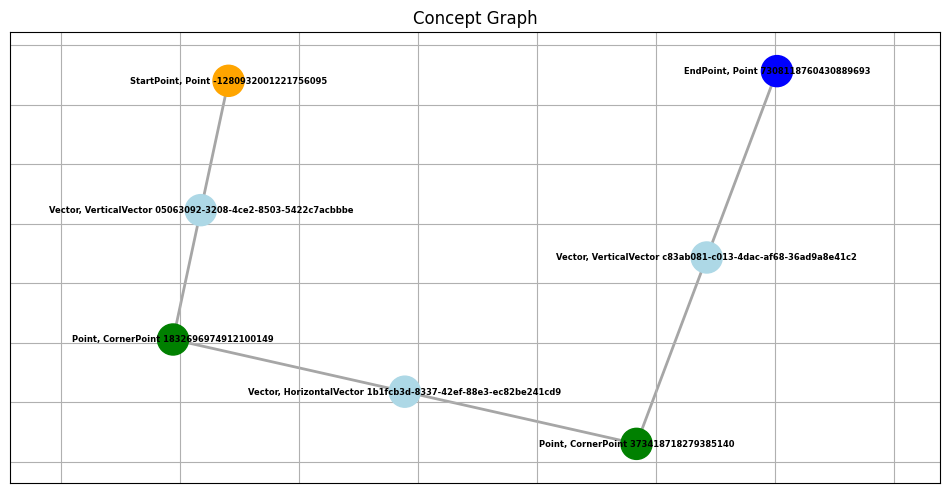

In [6]:
session_id = "4_2"
concept_name = session_id
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)

concept_result = service.create_concept_incrementally(
    session_id, 
    concept_name, 
    steps=2,
    debug_mode=True
    # debug_mode=False
)
concept_graph = concept_result.concept_graph
if concept_result.is_error:
    raise ValueError(concept_result.error_message)
visualize_graph(concept_graph)

In [7]:
for node in concept_graph:
    print(f"Node: {node}")
    for prop, val in concept_graph.nodes[node].items():
        print(f"Prop: {prop} = {val}")
    print("===============")

Node: -1280932001221756095
Prop: labels = ['StartPoint', 'Point']
Prop: session_id = 4_2
Prop: endpoints_count = {'min': 3.0, 'max': 4.0, 'center': 3.5, 'type': 'range'}
Prop: cycle_count = {'min': 0.0, 'max': 0.0, 'center': 0.0, 'type': 'range'}
Prop: vectors_count = {'min': 4.0, 'max': 5.0, 'center': 4.5, 'type': 'range'}
Prop: contour_type = OPEN
Prop: image_id = None
Prop: id = {'min': -1.2809320012217562e+18, 'max': 7.182301756564955e+18, 'center': 2.9506848776715996e+18, 'type': 'range'}
Prop: normalized_x = {'min': -0.5, 'max': -0.4, 'center': -0.45, 'type': 'range'}
Prop: normalized_y = {'min': -0.8, 'max': -0.5, 'center': -0.65, 'type': 'range'}
Prop: monotony = NON_MONOTONIC
Prop: intersection_points_count = {'min': 1.0, 'max': 2.0, 'center': 1.5, 'type': 'range'}
Prop: corner_points_count = {'min': 2.0, 'max': 2.0, 'center': 2.0, 'type': 'range'}
Prop: quadrant_change_count = {'min': 0.0, 'max': 0.0, 'center': 0.0, 'type': 'range'}
Prop: y = {'min': 22.596084796118102, 'max'

--- Step 1/2 ---
Description: Initial concept
Processing Image ID: f3482aa8-5f5b-40bc-b2e3-c70006ba438e
Step Start Point segments: No segments found


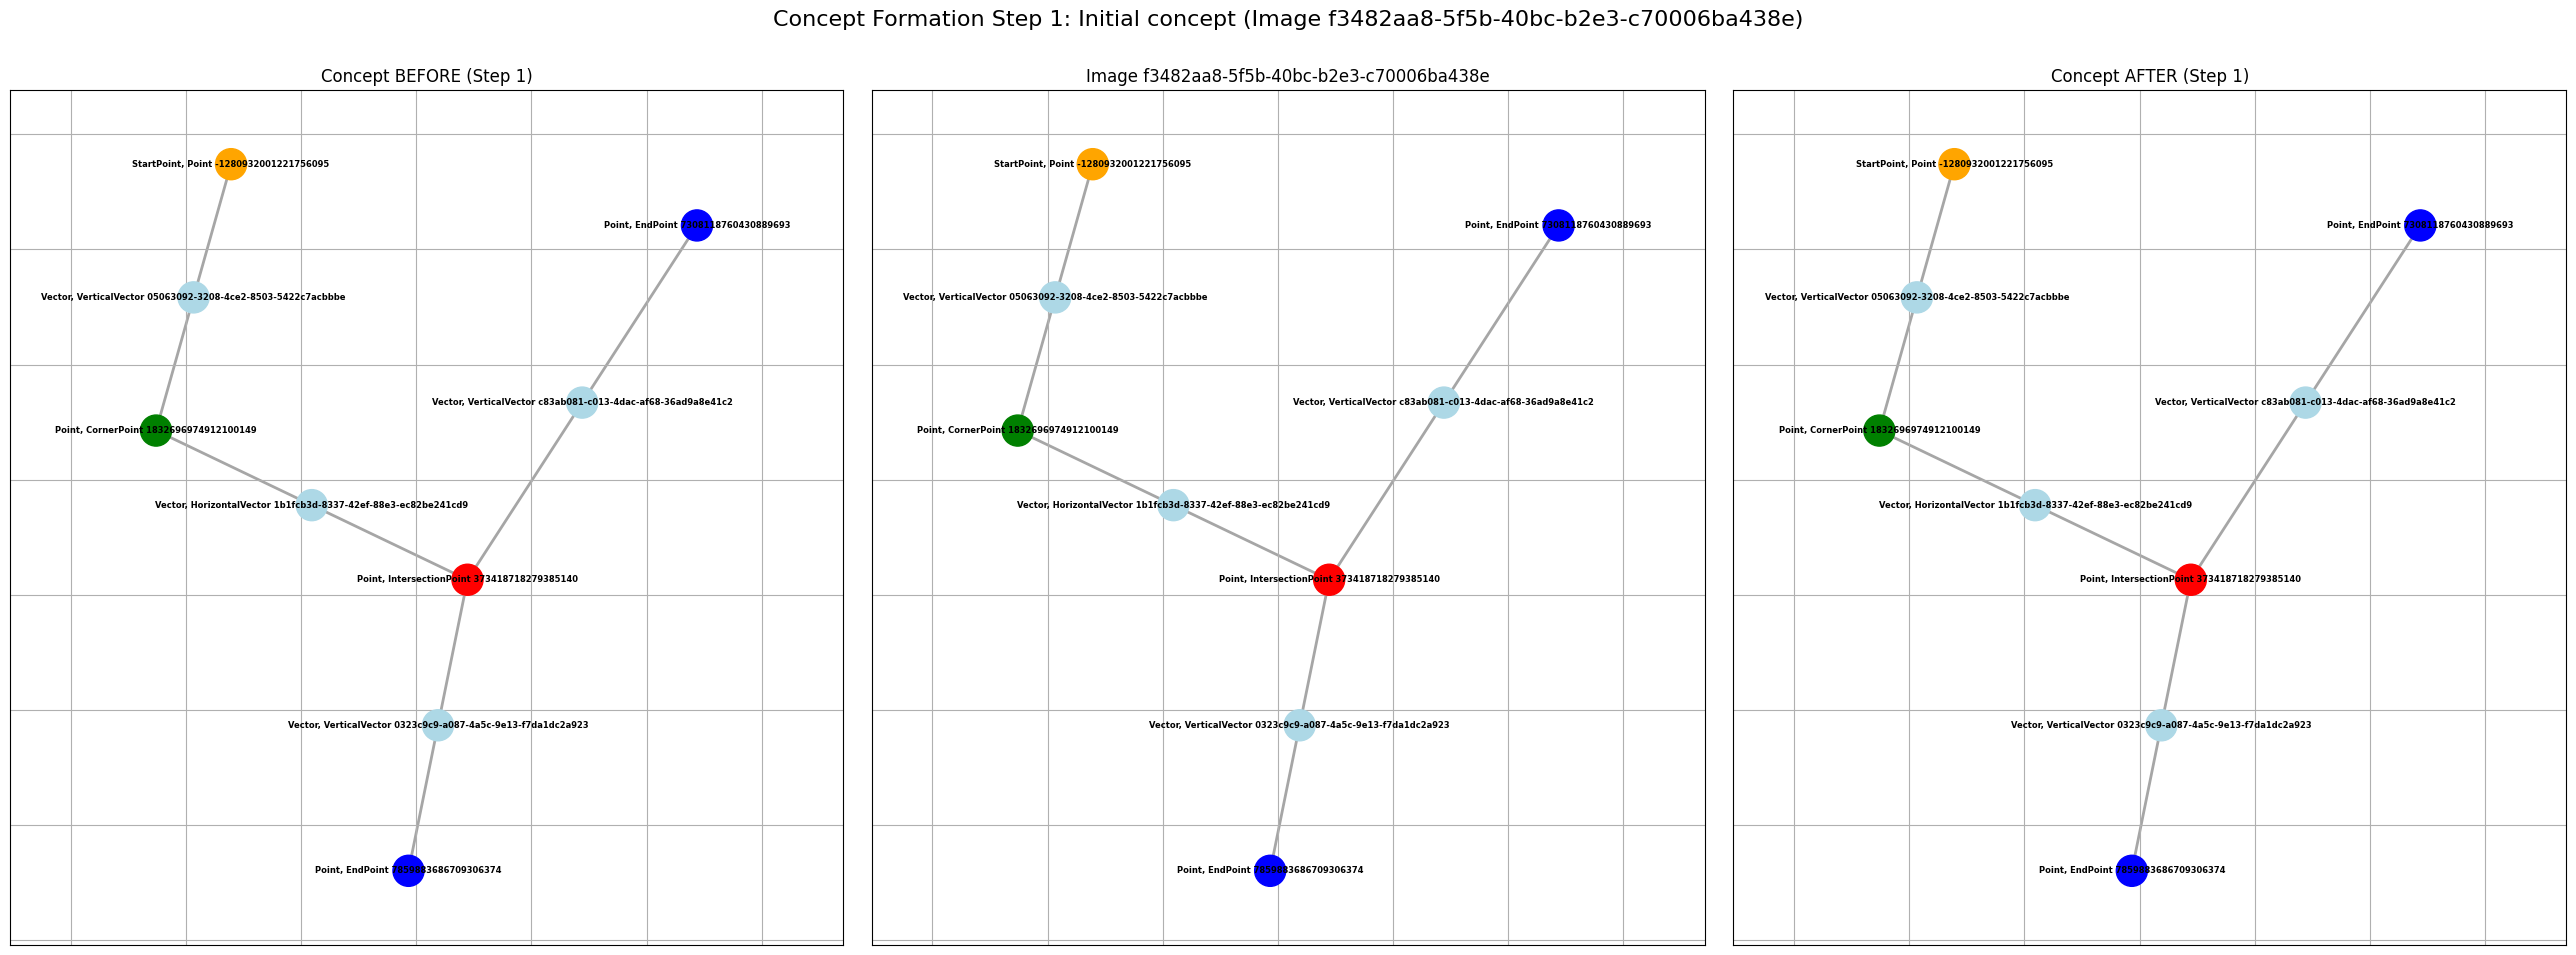

----------------------------------------
--- Step 2/2 ---
Description: Processing image 2/108: 3101aa46-5e95-4c35-ae14-329de0f9f6c6
Processing Image ID: 3101aa46-5e95-4c35-ae14-329de0f9f6c6
Step Start Point segments: No segments found


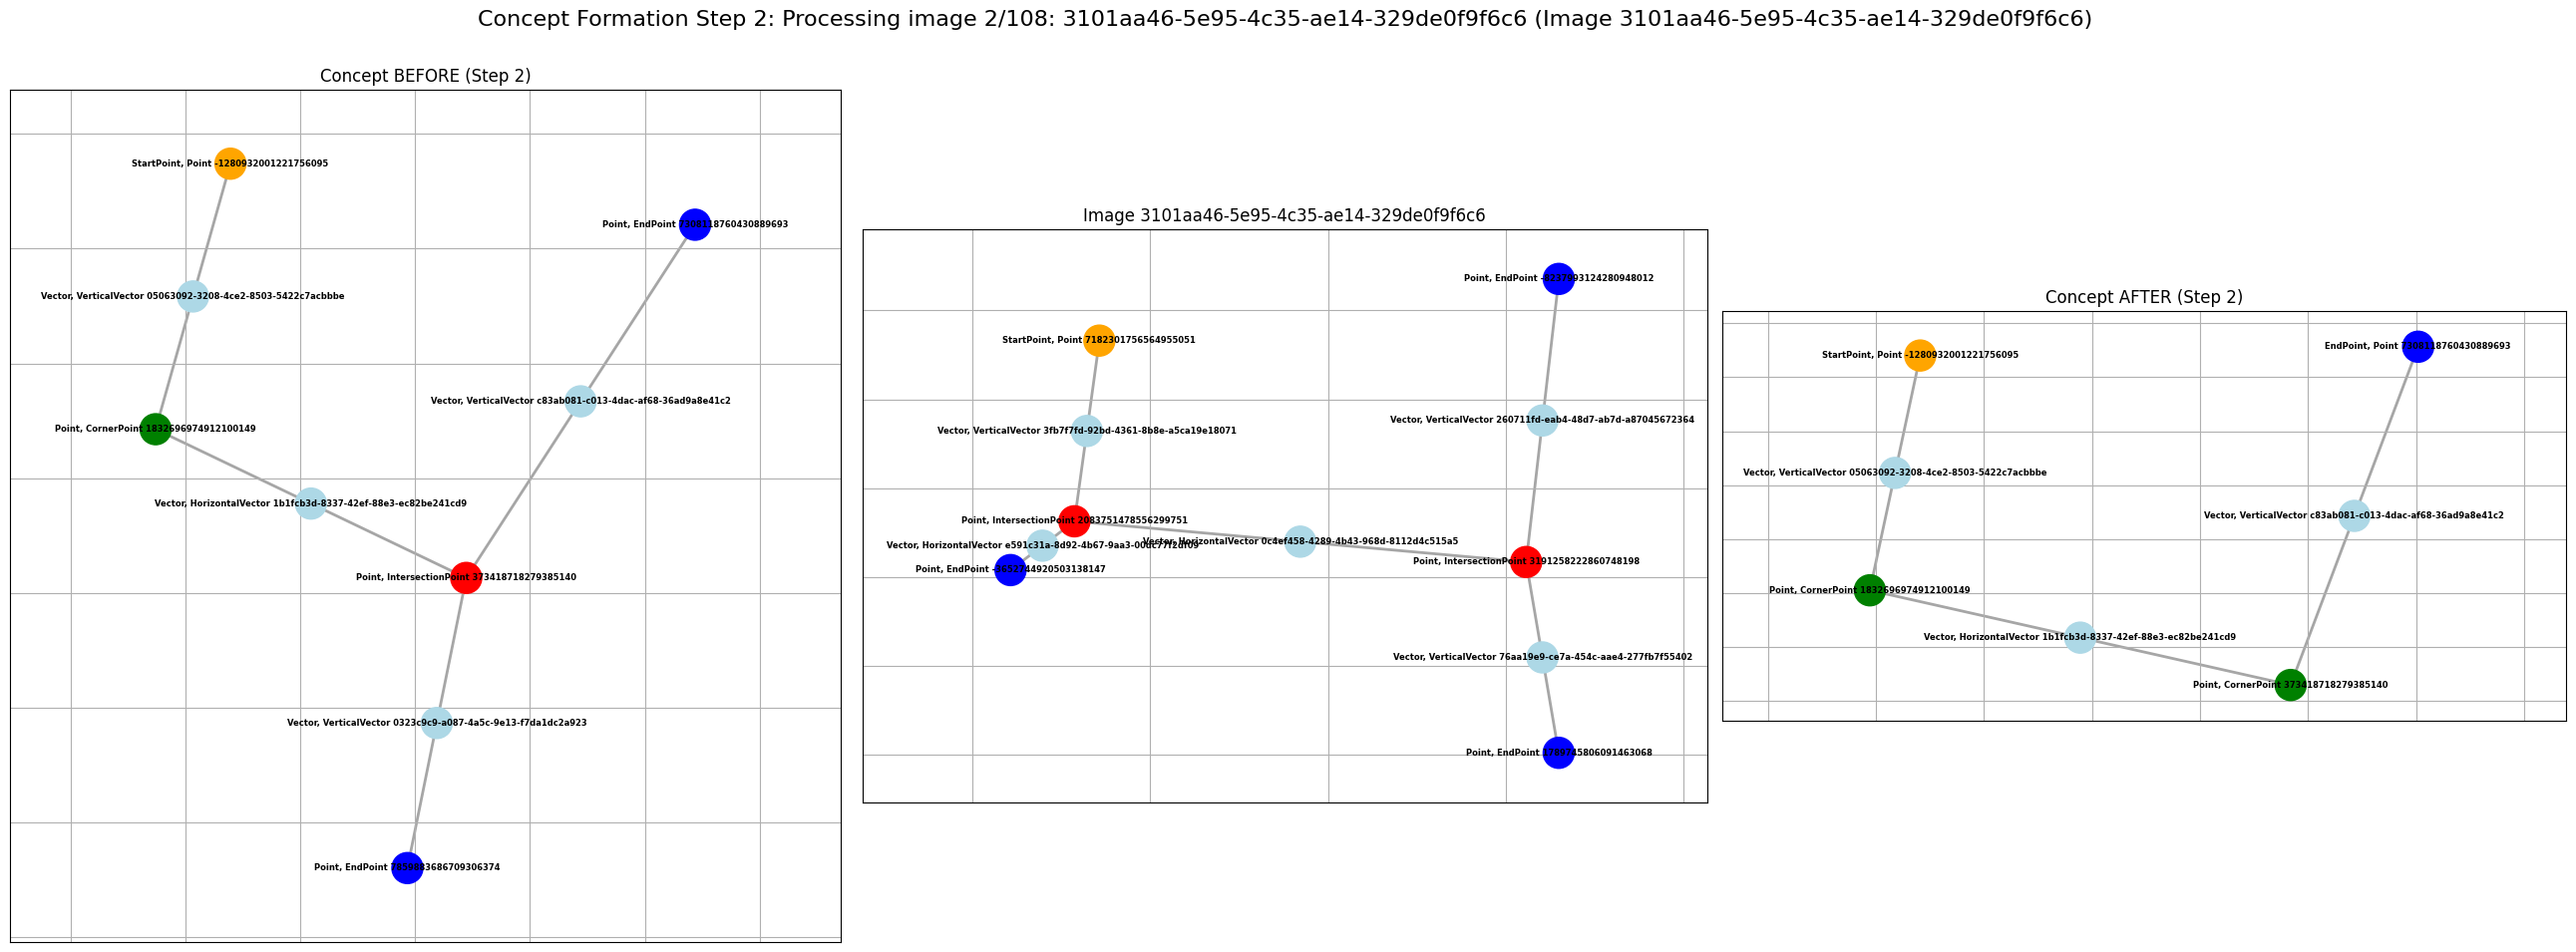

----------------------------------------


In [8]:
# visualize_graph(concept_graph)
visualize_concept_formation_steps(concept_result)

In [ ]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

# Create a directory for saved graphs if it doesn't exist
save_dir = "saved_graphs"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Convert the graph to a JSON-serializable format
graph_data = nx.node_link_data(concept_graph)

# Save the graph with a descriptive filename
json_filename = os.path.join(save_dir, "concept_graph.json")
with open(json_filename, "w") as f:
    json.dump(graph_data, f, indent=2)

print(f"Graph saved to {json_filename} in JSON format")



In [ ]:
def _load_graph(json_filename: str) -> nx.Graph:
    with open(json_filename, "r") as f:
        graph_data = json.load(f)
    return nx.node_link_graph(graph_data)

dir_path = "saved_graphs"
iteration = 1
graph1 = _load_graph(f"{dir_path}/{iteration}/graph1.json")
graph2 = _load_graph(f"{dir_path}/{iteration}/graph2.json")
crit_graph1 = _load_graph(f"{dir_path}/{iteration}/crit_graph1.json")
crit_graph2 = _load_graph(f"{dir_path}/{iteration}/crit_graph2.json")

visualize_graph(graph1)
visualize_graph(graph2)
visualize_graph(crit_graph1)
visualize_graph(crit_graph2)


In [ ]:
classes_to_subclasses = {
    # 0: [1],
    1: [1, 2, 3],
    2: [1, 2],
    3: [1],
    4: [1, 2],
    5: [1],
    6: [1],
    7: [1, 2],
    8: [1, 2],
    9: [1, 2],
}

# def generate_session_id(class_id: int, subclass_id: int) -> str:
#     return f"{class_id}_{subclass_id}"

# failed_concepts_to_reason = {}

# for class_id in classes_to_subclasses.keys():
#     for subclass_id in classes_to_subclasses[class_id]:
#         try:
#             session_id = generate_session_id(class_id, subclass_id)
#             service = CriticalPointConceptService(uri, user, password)
#             concept_result = service.create_concept_incrementally(
#                 session_id, 
#                 concept_id=session_id, 
#                 # steps=4,
#                 debug_mode=True
#             )
#         except Exception as error:
#             failed_concepts_to_reason[session_id] = str(error)
#         if concept_result.is_error:
#             failed_concepts_to_reason[session_id] = concept_result.error_message

# print(f"Failed concepts: {failed_concepts_to_reason.keys()}")
# Failed concepts: ['2_1', '2_2', '3_2', '4_1', '4_2', '5_1', '5_3', '6_2', '6_3', '7_2', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['2_2', '2_3', '3_2', '4_1', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['2_2', '4_1', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['2_2', '3_2', '4_1', '5_1', '5_3', '6_3', '7_2', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['1_1', '2_1', '2_2', '4_1', '5_1', '5_2', '5_3', '6_3', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['3_1', '4_1', '5_1', '6_1', '7_2', '8_1', '8_2', '9_1']
# Failed concepts: ['4_1', '5_1', '6_1', '7_2', '8_1', '8_2', '9_1']

In [ ]:
# total_concepts = sum(len(subclasses) for subclasses in classes_to_subclasses.values())
# failure_rate = len(failed_concepts) / total_concepts * 100
# print(f'Total concepts: {total_concepts}, Failure rate: {failure_rate:.1f}%')

In [ ]:
# from IPython.display import Image, display
# import os
# import shutil
# import imageio
# import matplotlib.pyplot as plt
# import networkx as nx
# import tempfile
# from typing import Callable


# def create_concept_formation_gif(
#     concept_result,
#     output_gif_path: str = "concept_formation.gif",
#     frame_duration: float = 0.5,
# ) -> str:
#     """
#     Generates a GIF animation visualizing the steps of concept formation.

#     Args:
#         concept_result: The ConceptResult object containing the formation steps.
#         output_gif_path: The path where the generated GIF will be saved.
#         frame_duration: Duration of each frame in the GIF (in seconds).

#     Returns:
#         The path to the generated GIF file.

#     Raises:
#         ValueError: If concept_result or steps_debug is None or empty.
#     """
#     if not concept_result or not concept_result.steps_debug:
#         raise ValueError("ConceptResult or its steps_debug cannot be None or empty.")

#     temp_dir = tempfile.mkdtemp()
#     frame_files = []

#     try:
#         for i, step in enumerate(concept_result.steps_debug):
#             fig, ax = plt.subplots(1, 2, figsize=(16, 12))
#             visualize_graph(
#                 step.current_concept,
#                 ax=ax[0],
#                 title=f"Step {step.current_step}/{len(concept_result.steps_debug)}",
#             )
#             visualize_graph(
#                 step.current_image,
#                 ax=ax[1],
#                 title="Incoming Image",
#             )
#             plt.tight_layout()
#             frame_filename = os.path.join(temp_dir, f"frame_{i:03d}.png")
#             plt.savefig(frame_filename)
#             plt.close(fig)  # Close the figure to free memory
#             frame_files.append(frame_filename)

#         # Add the final resulted concept as the last frame
#         if concept_result.concept_graph:
#             fig, ax = plt.subplots(figsize=(16, 12))
#             visualize_graph(
#                 step.current_concept,
#                 ax=ax,
#                 title=f"Final Concept\nConcept ID: {concept_result.concept_id}",
#             )

#             plt.tight_layout()
#             frame_filename = os.path.join(temp_dir, f"frame_{len(frame_files):03d}.png")
#             plt.savefig(frame_filename)
#             plt.close(fig)
#             frame_files.append(frame_filename)

#         # Create the GIF
#         images = [imageio.imread(frame) for frame in frame_files]
#         imageio.mimsave(output_gif_path, images, duration=frame_duration)

#         print(f"GIF saved to: {output_gif_path}")
#         return output_gif_path

#     finally:
#         # Clean up temporary directory
#         shutil.rmtree(temp_dir)

# """  """
# def get_pos(graph: nx.Graph) -> dict:
#     # Extract node positions from the graph
#     pos = {}
#     for node_id, node_data in graph.nodes(data=True):
#         # For regular points
#         if "x" in node_data and "y" in node_data:
#             x = (
#                 node_data["x"]["center"]
#                 if isinstance(node_data["x"], dict) and "center" in node_data["x"]
#                 else node_data["x"]
#             )
#             y = (
#                 node_data["y"]["center"]
#                 if isinstance(node_data["y"], dict) and "center" in node_data["y"]
#                 else node_data["y"]
#             )

#             pos[node_id] = (x, y)

#         if "labels" in node_data and "Vector" in node_data["labels"]:
#             x1 = node_data["x1"]
#             x2 = node_data["x2"]
#             y1 = node_data["y1"]
#             y2 = node_data["y2"]

#             x1 = x1["center"] if isinstance(x1, dict) and "center" in x1 else x1
#             x2 = x2["center"] if isinstance(x2, dict) and "center" in x2 else x2
#             y1 = y1["center"] if isinstance(y1, dict) and "center" in y1 else y1
#             y2 = y2["center"] if isinstance(y2, dict) and "center" in y2 else y2

#             # Calculate midpoint for vectors
#             pos[node_id] = ((x1 + x2) / 2, (y1 + y2) / 2)
#     return pos


# gif_path = create_concept_formation_gif(
#     concept_result, output_gif_path="my_concept_animation.gif", frame_duration=1000
# )

# # Optional: Display the GIF in the notebook (if using IPython)
# display(Image(filename=gif_path))

In [ ]:
from neo4j import GraphDatabase

def remove_image_data(driver, image_id: str) -> None:
    """
    Remove all data for an image from the Neo4j database.
    
    Args:
        driver: Neo4j driver instance
        image_id: ID of the image to remove
    """
    with driver.session() as session:
        session.execute_write(lambda tx: _remove_image_data(tx, image_id))
        print(f"Successfully removed data for image {image_id}")

def _remove_image_data(tx, image_id: str) -> None:
        """Remove all data for an image."""
        # First remove relationships
        query = """
        MATCH (n)
        WHERE n.image_id = $image_id OR $image_id IN n.samples
        DETACH DELETE n
        """
        tx.run(query, image_id=image_id)

driver = GraphDatabase.driver(uri, auth=(user, password))
remove_image_data(driver, "746d2efc-85d5-4be2-9a47-99699f929397")
driver.close()